# Holdout Validation + SHAP Error Analysis (`lr_elasticnet`)

This notebook performs a stratified 80/20 holdout validation analysis for the winning full-feature `lr_elasticnet` model.

Key constraints followed:
- Leakage-safe training: preprocessing is inside the sklearn pipeline and fit only on training split.
- Explicit class decision rule: `y_pred = (y_proba >= 0.50).astype(int)`.
- tests are exploratory and only run when subgroup counts are adequate


In [ ]:
from __future__ import annotations

from pathlib import Path
import sys
import warnings
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.model_selection import train_test_split

from sklearn.metrics import confusion_matrix

try:
    from scipy.stats import kruskal, chi2_contingency
except ImportError:
    kruskal = None
    chi2_contingency = None

try:
    import shap
except ImportError as exc:
    raise ImportError("This notebook requires `shap`. Install with: pip install shap") from exc

warnings.filterwarnings(
    'ignore',
    message='X does not have valid feature names, but .* was fitted with feature names',
    category=UserWarning,
)
warnings.filterwarnings(
    'ignore',
    message='.*tight_layout.*',
    category=UserWarning,
)
warnings.filterwarnings(
    'ignore',
    message='DataFrameGroupBy.apply operated on the grouping columns.*',
    category=FutureWarning,
)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120


In [ ]:
SEED = 42
TEST_SIZE = 0.20
THRESHOLD = 0.50

def find_repo_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "src").is_dir() and (candidate / "data" / "students_dataset.csv").is_file():
            return candidate
    raise RuntimeError("Could not locate repository root containing src/ and data/students_dataset.csv")

repo_root = find_repo_root(Path.cwd())

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src.model_specs import make_pipeline
from sklearn.linear_model import LogisticRegression
from src.metrics_utils import compute_metrics


data_path = repo_root / 'data' / 'students_dataset.csv'
metadata_path = repo_root / 'models' / 'final_model_metadata.json'
out_dir = repo_root / 'figures' / 'validation_error_analysis'
out_dir.mkdir(parents=True, exist_ok=True)

print(f"Repo root: {repo_root}")
print(f"Dataset path: {Path('data/students_dataset.csv')}")
print(f"Metadata path: {Path('models/final_model_metadata.json')}")
print(f"Output dir: {Path('figures/validation_error_analysis')}")
print(f"Seed={SEED}, test_size={TEST_SIZE}, threshold={THRESHOLD}")


Repo root: /Users/pstamatop/Documents/DSIT/MLCB/Assignments/Assignment 2/mlcb-heart-disease-rncv
Dataset path: data/students_dataset.csv
Metadata path: models/final_model_metadata.json
Output dir: figures/validation_error_analysis
Seed=42, test_size=0.2, threshold=0.5


In [28]:
with metadata_path.open('r', encoding='utf-8') as f:
    metadata = json.load(f)

print('Winner algorithm:', metadata['winner_algorithm'])
print('Saved tuned hyperparameters:', metadata['final_hyperparameters'])
print('Model path from metadata:', metadata['model_path'])

feature_groups = metadata['feature_groups']
numeric_features = feature_groups['numeric_features']
binary_features = feature_groups['binary_features']
categorical_features = feature_groups['categorical_features']
ordinal_features = feature_groups['ordinal_features']


Winner algorithm: lr_elasticnet
Saved tuned hyperparameters: {'model__C': 4.570563099801454, 'model__l1_ratio': 0.5986584841970366}
Model path from metadata: models/final_lr_elasticnet_pipeline.pkl


In [29]:
df = pd.read_csv(data_path)
X = df.drop(columns=['num']).copy()
y = df['num'].astype(int).copy()

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=y,
)

print('Full dataset shape:', df.shape)
print('Train shape:', X_train.shape, '| Validation shape:', X_val.shape)
print('Train class distribution:')
print(y_train.value_counts(normalize=True).sort_index())
print('Validation class distribution:')
print(y_val.value_counts(normalize=True).sort_index())


Full dataset shape: (242, 14)
Train shape: (193, 13) | Validation shape: (49, 13)
Train class distribution:
num
0    0.53886
1    0.46114
Name: proportion, dtype: float64
Validation class distribution:
num
0    0.55102
1    0.44898
Name: proportion, dtype: float64


## Train Holdout Model (training split only)

Pipeline is rebuilt from the same full-feature specification and fitted only on `X_train, y_train`


In [30]:
lr_estimator = LogisticRegression(
    penalty='elasticnet',
    solver='saga',
    max_iter=5000,
    random_state=SEED,
)
base_pipeline = make_pipeline(
    estimator=lr_estimator,
    numeric_features=numeric_features,
    categorical_features=categorical_features,
    binary_features=binary_features,
    ordinal_features=ordinal_features,
)

pipeline = clone(base_pipeline)
pipeline.set_params(**metadata['final_hyperparameters'])
pipeline.fit(X_train, y_train)

print('Pipeline trained on training split only.')


Pipeline trained on training split only.


## Validation Predictions and Metrics

Decision rule is explicitly probability-threshold based:

`y_proba = pipeline.predict_proba(X_val)[:, 1]`

`y_pred = (y_proba >= 0.50).astype(int)`


In [31]:
y_true = y_val.to_numpy()
y_proba = pipeline.predict_proba(X_val)[:, 1]
y_pred = (y_proba >= THRESHOLD).astype(int)

metrics = compute_metrics(y_true=y_true, y_pred=y_pred, y_score=y_proba)
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

tn, fp, fn, tp = cm.ravel()
print('Confusion matrix [[TN, FP], [FN, TP]]:')
print(cm)
print('Validation metrics:')
for k in ['mcc', 'roc_auc', 'pr_auc', 'balanced_accuracy', 'f1', 'recall', 'specificity', 'precision']:
    print(f"{k}: {metrics[k]:.4f}")

print(f"Counts -> TN={tn}, FP={fp}, FN={fn}, TP={tp}")


Confusion matrix [[TN, FP], [FN, TP]]:
[[22  5]
 [ 5 17]]
Validation metrics:
mcc: 0.5875
roc_auc: 0.9343
pr_auc: 0.9359
balanced_accuracy: 0.7938
f1: 0.7727
recall: 0.7727
specificity: 0.8148
precision: 0.7727
Counts -> TN=22, FP=5, FN=5, TP=17


The model performs very well on this holdout (ROC-AUC 0.934, PR-AUC 0.936), and errors are balanced (5 false positives, 5 false negatives).
This means the current threshold is not biased toward either too many alarms or too many misses, so the next step is to tune it based on clinical priorities.

In [32]:
analysis_df = X_val.reset_index(drop=False).rename(columns={'index': 'row_index'}).copy()
analysis_df['y_true'] = y_true
analysis_df['y_proba'] = y_proba
analysis_df['y_pred'] = y_pred

analysis_df['error_type'] = np.select(
    [
        (analysis_df['y_true'] == 1) & (analysis_df['y_pred'] == 1),
        (analysis_df['y_true'] == 0) & (analysis_df['y_pred'] == 0),
        (analysis_df['y_true'] == 0) & (analysis_df['y_pred'] == 1),
        (analysis_df['y_true'] == 1) & (analysis_df['y_pred'] == 0),
    ],
    ['TP', 'TN', 'FP', 'FN'],
    default='UNKNOWN'
)
analysis_df['group'] = np.where(analysis_df['error_type'].isin(['FP', 'FN']), analysis_df['error_type'], 'Correct')

analysis_path = out_dir / 'validation_predictions_with_errors.csv'
analysis_df.to_csv(analysis_path, index=False)

print(f"Saved per-sample validation table to: {Path('figures/validation_error_analysis/validation_predictions_with_errors.csv')}")
print('Group counts:')
print(analysis_df['group'].value_counts())


Saved per-sample validation table to: figures/validation_error_analysis/validation_predictions_with_errors.csv
Group counts:
group
Correct    39
FN          5
FP          5
Name: count, dtype: int64


## Descriptive Error Analysis (Primary)

Given the small holdout size, this section prioritizes counts, summary statistics and visual inspection.


Age summary by group (FP/FN/Correct):
         count    mean  median    std   min   max
group                                            
Correct     39  55.359    55.0  8.707  37.0  77.0
FN           5  49.000    52.0  8.972  38.0  57.0
FP           5  56.400    57.0  8.792  43.0  66.0


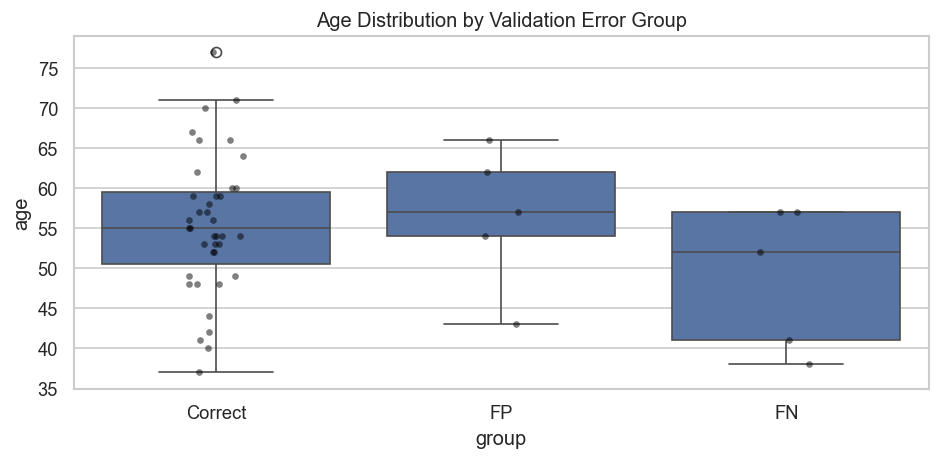

In [33]:
def describe_by_group(frame: pd.DataFrame, col: str) -> pd.DataFrame:
    return (
        frame.groupby('group')[col]
        .agg(['count', 'mean', 'median', 'std', 'min', 'max'])
        .sort_index()
        .round(3)
    )

age_desc = describe_by_group(analysis_df, 'age')
print('Age summary by group (FP/FN/Correct):')
print(age_desc)

plt.figure(figsize=(8, 4))
sns.boxplot(data=analysis_df, x='group', y='age', order=['Correct', 'FP', 'FN'])
sns.stripplot(data=analysis_df, x='group', y='age', order=['Correct', 'FP', 'FN'], color='black', size=4, alpha=0.5)
plt.title('Age Distribution by Validation Error Group')
plt.tight_layout()
plt.savefig(out_dir / 'age_distribution_by_group.png', bbox_inches='tight')
plt.show()


In [34]:
numeric_focus = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
cat_focus = ['sex', 'fbs', 'exang', 'cp', 'restecg', 'slope', 'thal']

for col in numeric_focus:
    print(f"Numeric feature: {col}")
    print(describe_by_group(analysis_df, col))

for col in cat_focus:
    print(f"Categorical/Binary feature: {col}")
    ctab = pd.crosstab(analysis_df['group'], analysis_df[col], normalize='index').round(3)
    counts = pd.crosstab(analysis_df['group'], analysis_df[col])
    print('Counts:')
    print(counts)
    print('Within-group proportions:')
    print(ctab)


Numeric feature: age
         count    mean  median    std   min   max
group                                            
Correct     39  55.359    55.0  8.707  37.0  77.0
FN           5  49.000    52.0  8.972  38.0  57.0
FP           5  56.400    57.0  8.792  43.0  66.0
Numeric feature: trestbps
         count     mean  median     std    min    max
group                                                
Correct     39  133.359   130.0  18.084  108.0  180.0
FN           5  125.200   120.0  17.922  110.0  154.0
FP           5  125.400   120.0  10.286  115.0  140.0
Numeric feature: chol
         count     mean  median     std    min    max
group                                                
Correct     39  256.231   258.0  48.462  168.0  353.0
FN           5  220.200   231.0  27.041  172.0  236.0
FP           5  292.800   302.0  68.925  207.0  394.0
Numeric feature: thalach
         count     mean  median     std    min    max
group                                                
Correct 

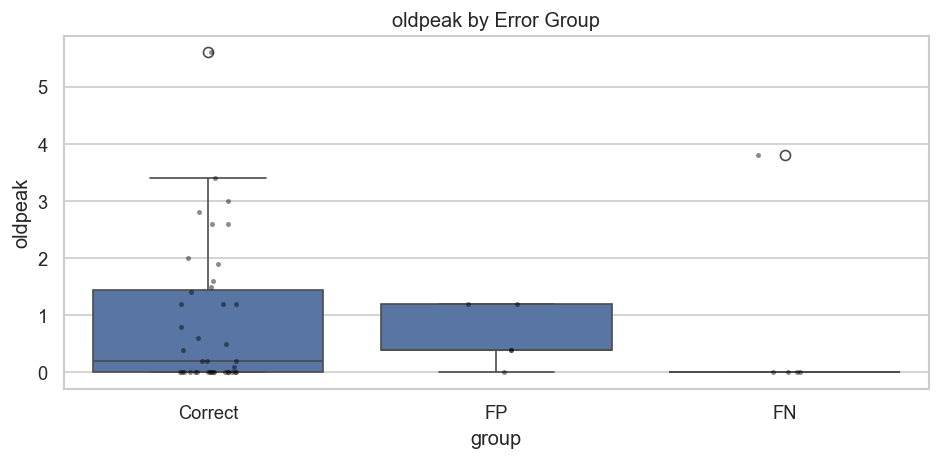

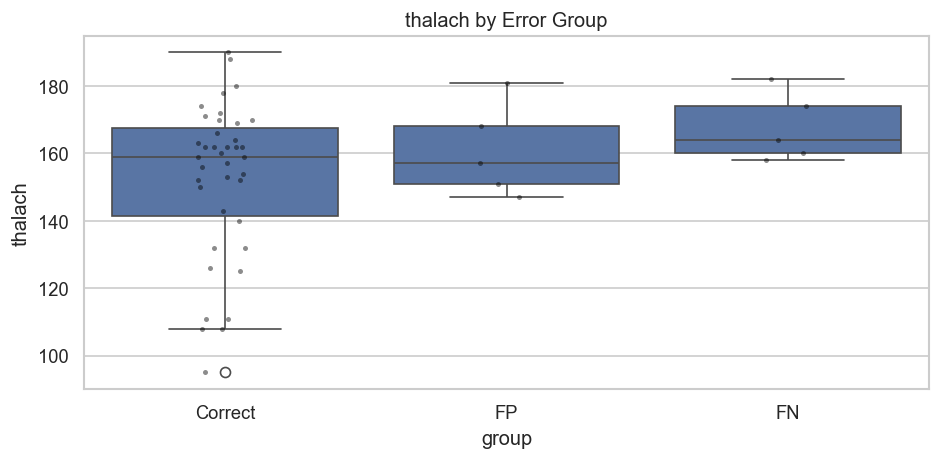

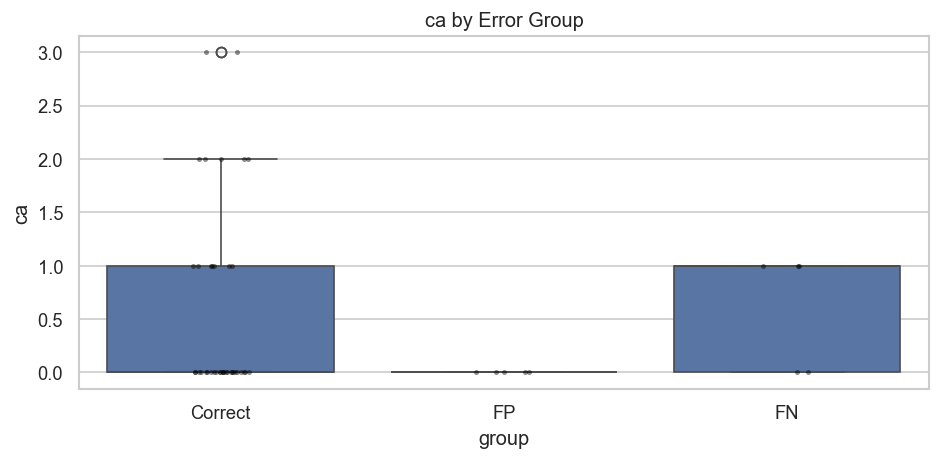

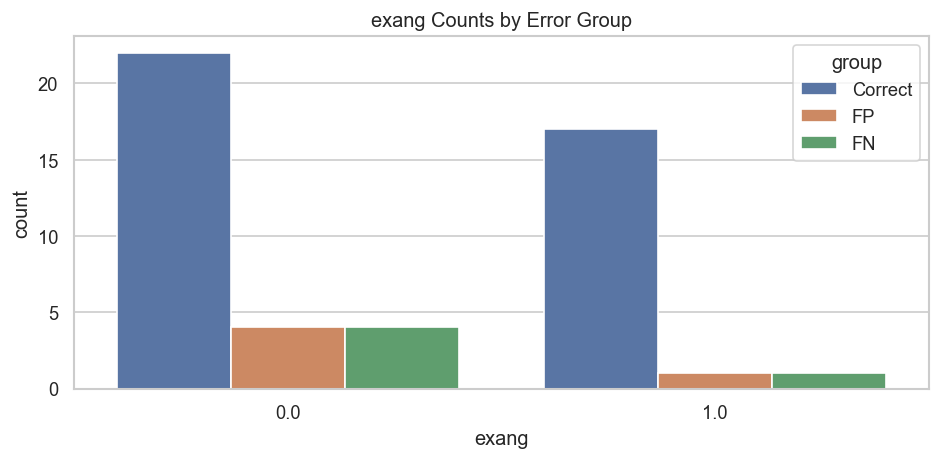

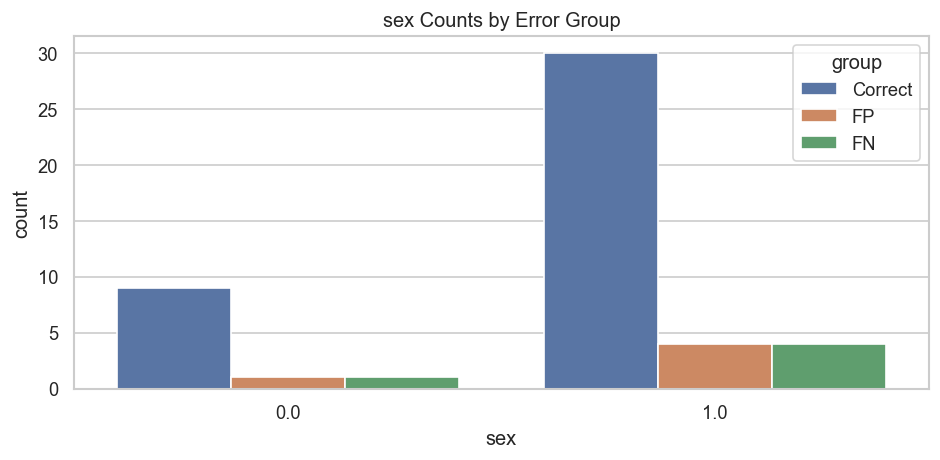

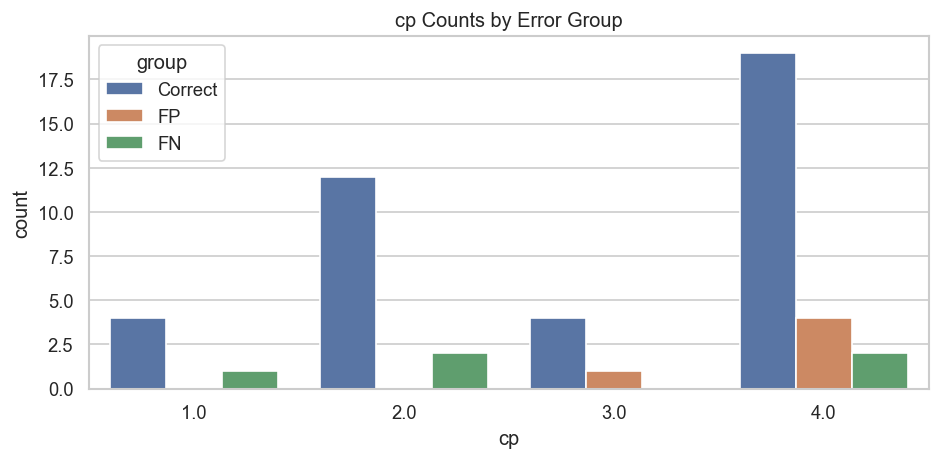

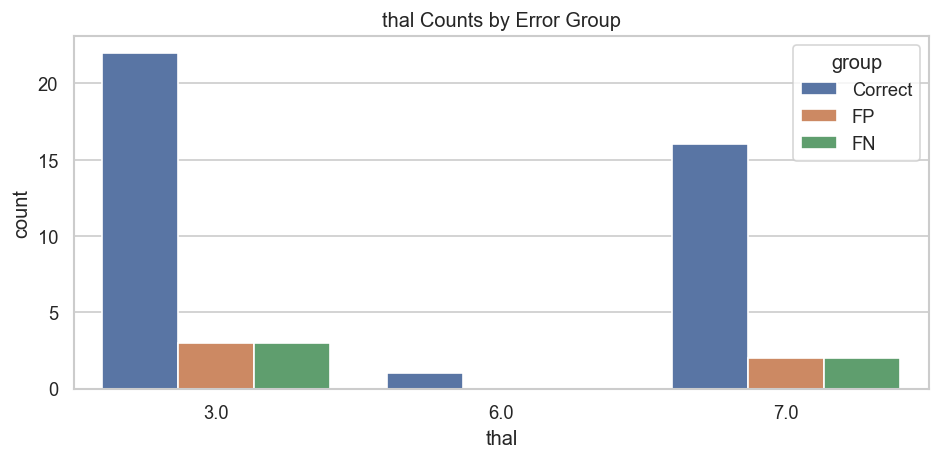

In [35]:
# Compact plot set for clinically relevant features.
plot_cols = ['oldpeak', 'thalach', 'ca']
for col in plot_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=analysis_df, x='group', y=col, order=['Correct', 'FP', 'FN'])
    sns.stripplot(data=analysis_df, x='group', y=col, order=['Correct', 'FP', 'FN'], color='black', size=3, alpha=0.45)
    plt.title(f'{col} by Error Group')
    plt.tight_layout()
    plt.savefig(out_dir / f'{col}_by_group.png', bbox_inches='tight')
    plt.show()

for col in ['exang', 'sex', 'cp', 'thal']:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=analysis_df, x=col, hue='group', hue_order=['Correct', 'FP', 'FN'])
    plt.title(f'{col} Counts by Error Group')
    plt.tight_layout()
    plt.savefig(out_dir / f'{col}_counts_by_group.png', bbox_inches='tight')
    plt.show()


The error-analysis plots should be interpreted cautiously because the validation set is small. Patterns are more useful when they appear consistently across related variables, rather than in a single feature alone.

## SHAP on Validation Set

SHAP values are computed from the trained holdout model and compared across `Correct`, `FP`, and `FN` groups.


In [36]:
fitted_preprocessor = pipeline.named_steps['preprocessor']
fitted_model = pipeline.named_steps['model']

X_val_transformed = fitted_preprocessor.transform(X_val)

def _cols_to_names(cols, X_ref):
    if cols is None:
        return []
    if isinstance(cols, slice):
        return [str(c) for c in X_ref.columns[cols]]
    if isinstance(cols, (list, tuple, np.ndarray, pd.Index)):
        if len(cols) == 0:
            return []
        first = cols[0]
        if isinstance(first, (bool, np.bool_)):
            return [str(c) for c, keep in zip(X_ref.columns, cols) if keep]
        if isinstance(first, (int, np.integer)):
            return [str(X_ref.columns[i]) for i in cols]
        return [str(c) for c in cols]
    return [str(cols)]

def _safe_feature_names(transformer, input_names):
    if transformer in ('drop', None):
        return []
    if transformer == 'passthrough':
        return [str(c) for c in input_names]
    if hasattr(transformer, 'steps'):
        current_names = [str(c) for c in input_names]
        for _, step in transformer.steps:
            if hasattr(step, 'get_feature_names_out'):
                try:
                    current_names = list(step.get_feature_names_out(current_names))
                except Exception:
                    try:
                        current_names = list(step.get_feature_names_out())
                    except Exception:
                        pass
        return [str(c) for c in current_names]
    if hasattr(transformer, 'get_feature_names_out'):
        try:
            return [str(c) for c in transformer.get_feature_names_out(input_names)]
        except Exception:
            try:
                return [str(c) for c in transformer.get_feature_names_out()]
            except Exception:
                pass
    return [str(c) for c in input_names]

try:
    transformed_feature_names = list(fitted_preprocessor.get_feature_names_out(X_val.columns))
except Exception:
    transformed_feature_names = []
    if hasattr(fitted_preprocessor, 'transformers_'):
        for _, transformer, cols in fitted_preprocessor.transformers_:
            input_names = _cols_to_names(cols, X_val)
            transformed_feature_names.extend(_safe_feature_names(transformer, input_names))
    if len(transformed_feature_names) != X_val_transformed.shape[1]:
        transformed_feature_names = [f'feature_{i}' for i in range(X_val_transformed.shape[1])]

# For linear logistic regression on transformed matrix.
explainer = shap.LinearExplainer(fitted_model, X_val_transformed)
shap_values = explainer.shap_values(X_val_transformed)

if isinstance(shap_values, list):
    shap_values = shap_values[1] if len(shap_values) > 1 else shap_values[0]

shap_values = np.asarray(shap_values)
print('SHAP matrix shape:', shap_values.shape)
print('Validation transformed shape:', X_val_transformed.shape)

if shap_values.shape != X_val_transformed.shape:
    raise RuntimeError('SHAP output shape does not match transformed validation shape.')


SHAP matrix shape: (49, 22)
Validation transformed shape: (49, 22)


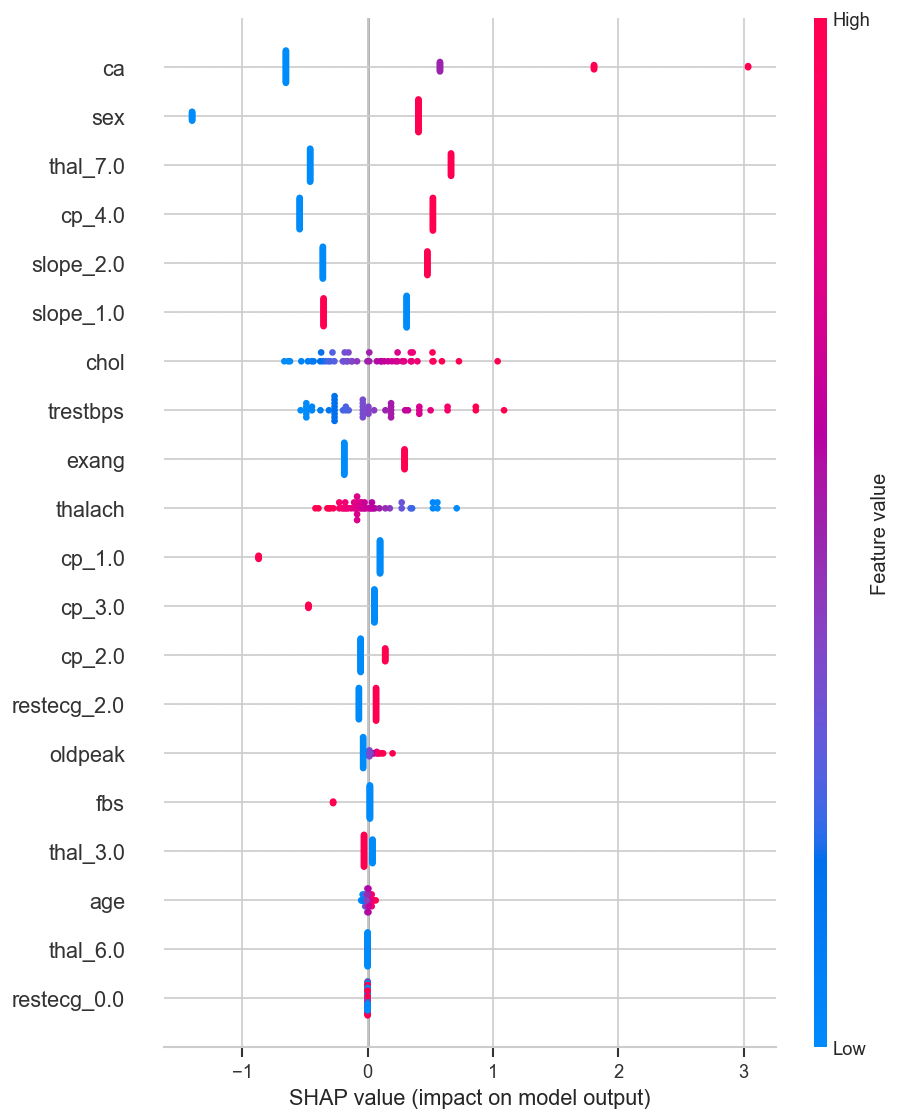

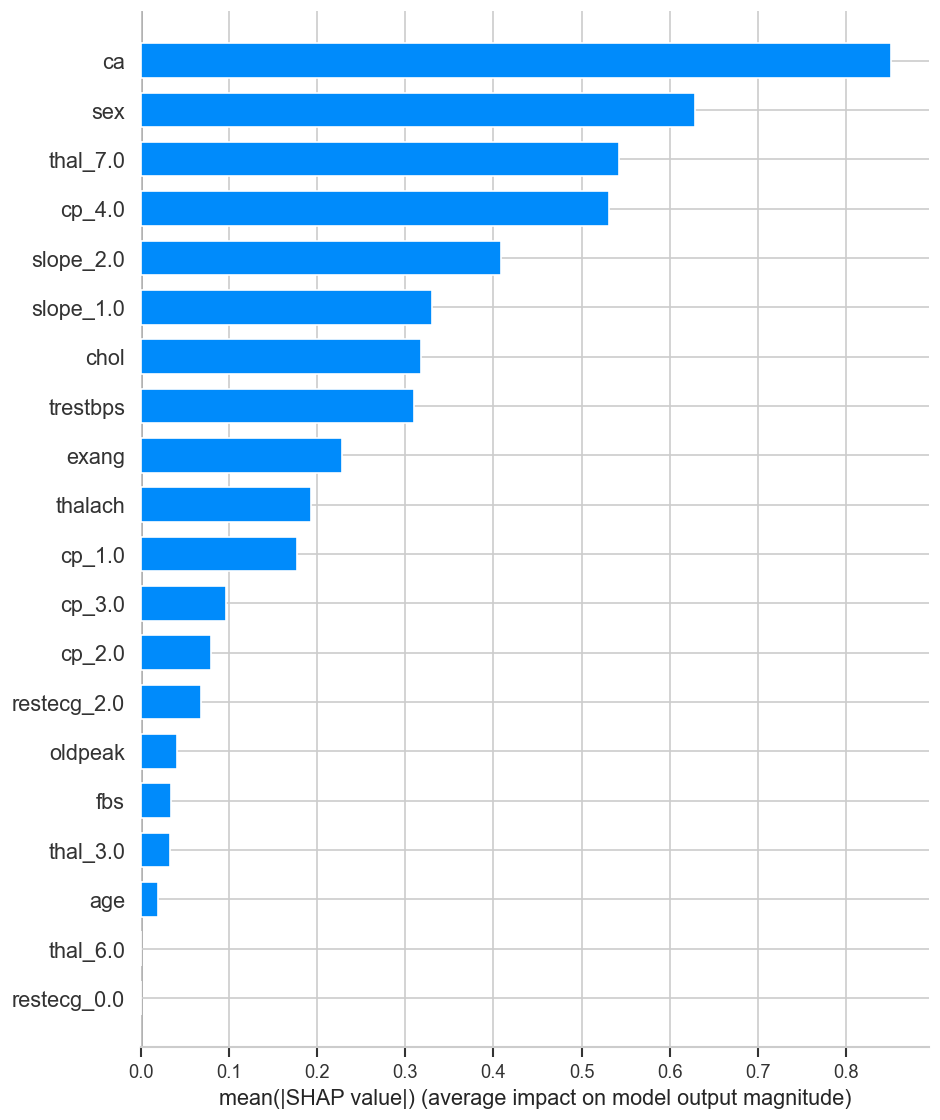

In [37]:
# Global SHAP summary plots.
plt.figure()
shap.summary_plot(shap_values, X_val_transformed, feature_names=transformed_feature_names, show=False)
plt.tight_layout()
plt.savefig(out_dir / 'shap_summary_beeswarm_validation.png', bbox_inches='tight')
plt.show()

plt.figure()
shap.summary_plot(shap_values, X_val_transformed, feature_names=transformed_feature_names, plot_type='bar', show=False)
plt.tight_layout()
plt.savefig(out_dir / 'shap_summary_bar_validation.png', bbox_inches='tight')
plt.show()


Global SHAP shows which features matter most overall.
Use it as a starting list, then check group SHAP to see if those features act differently in FP vs FN.

In [38]:
group_index = analysis_df.reset_index(drop=True)['group']
shap_df = pd.DataFrame(shap_values, columns=transformed_feature_names)
shap_df['group'] = group_index.values

mean_abs_by_group = (
    shap_df.groupby('group')
    .apply(lambda g: g.abs().mean(), include_groups=False)
    .T
)

# Top features by overall importance.
overall_top = shap_df.drop(columns=['group']).abs().mean().sort_values(ascending=False)
top_features = overall_top.head(12).index.tolist()

mean_abs_by_group.loc[top_features].to_csv(out_dir / 'top12_mean_abs_shap_by_group.csv')
print('Top features by overall mean(|SHAP|):')
print(overall_top.head(12).round(4))

print('Mean(|SHAP|) by group for top features:')
print(mean_abs_by_group.loc[top_features].round(4))


Top features by overall mean(|SHAP|):
ca           0.8515
sex          0.6286
thal_7.0     0.5428
cp_4.0       0.5310
slope_2.0    0.4083
slope_1.0    0.3300
chol         0.3177
trestbps     0.3099
exang        0.2282
thalach      0.1927
cp_1.0       0.1775
cp_3.0       0.0963
dtype: float64
Mean(|SHAP|) by group for top features:
group      Correct      FN      FP
ca          0.9084  0.6068  0.6519
sex         0.6348  0.6042  0.6042
thal_7.0    0.5432  0.5411  0.5411
cp_4.0      0.5315  0.5334  0.5247
slope_2.0   0.4030  0.4049  0.4525
slope_1.0   0.3308  0.3353  0.3191
chol        0.3101  0.2716  0.4232
trestbps    0.3166  0.3476  0.2195
exang       0.2333  0.2079  0.2079
thalach     0.2066  0.1506  0.1259
cp_1.0      0.1779  0.2530  0.0988
cp_3.0      0.0966  0.0536  0.1373


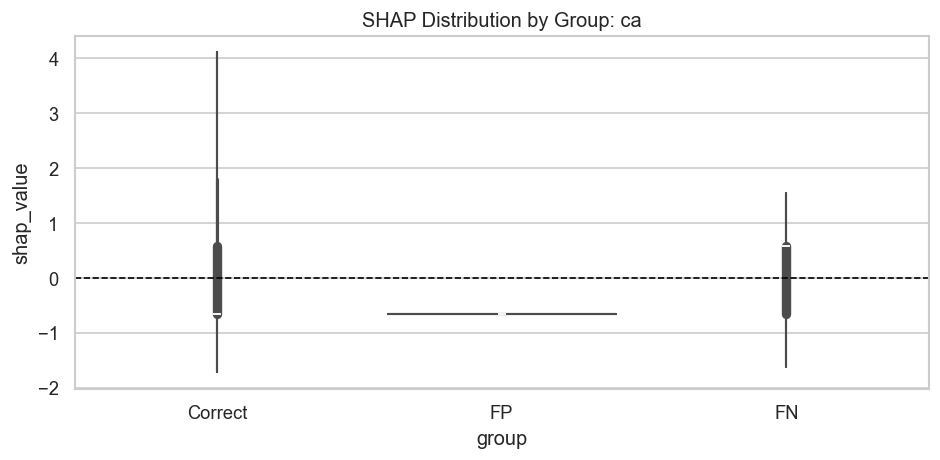

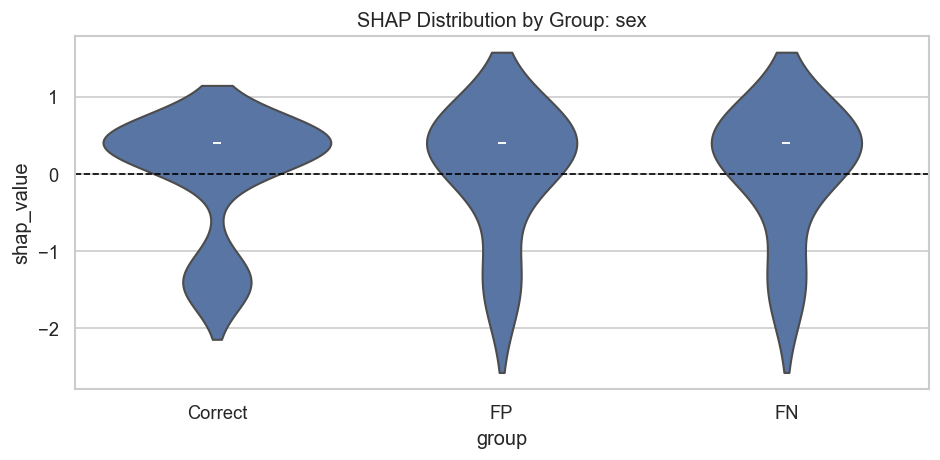

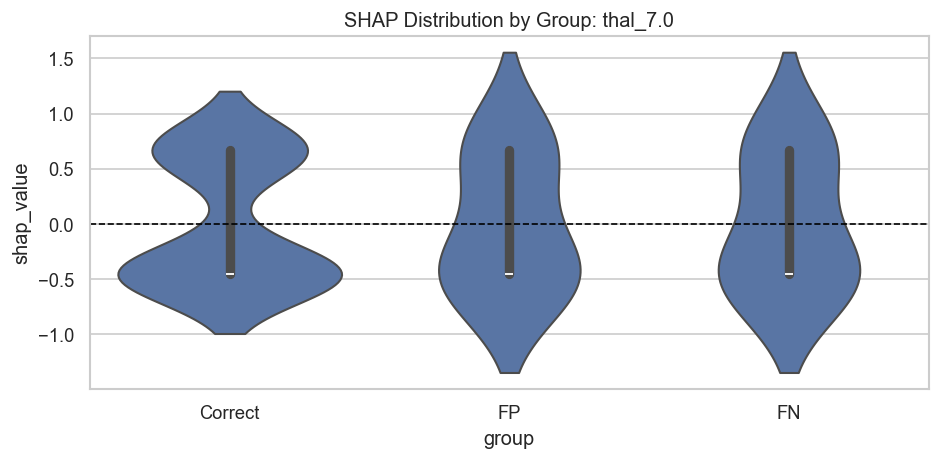

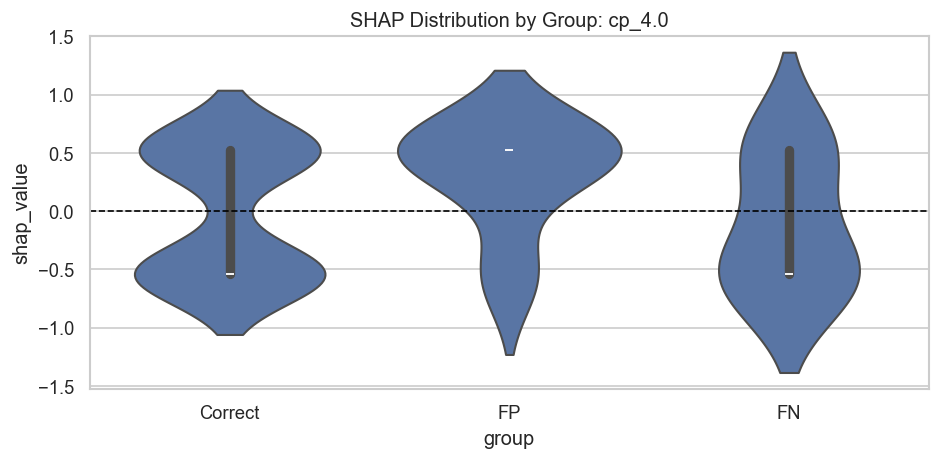

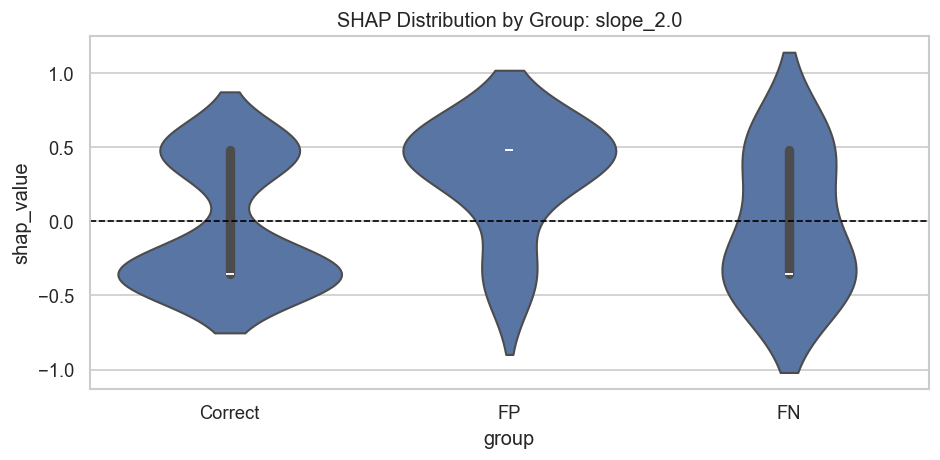

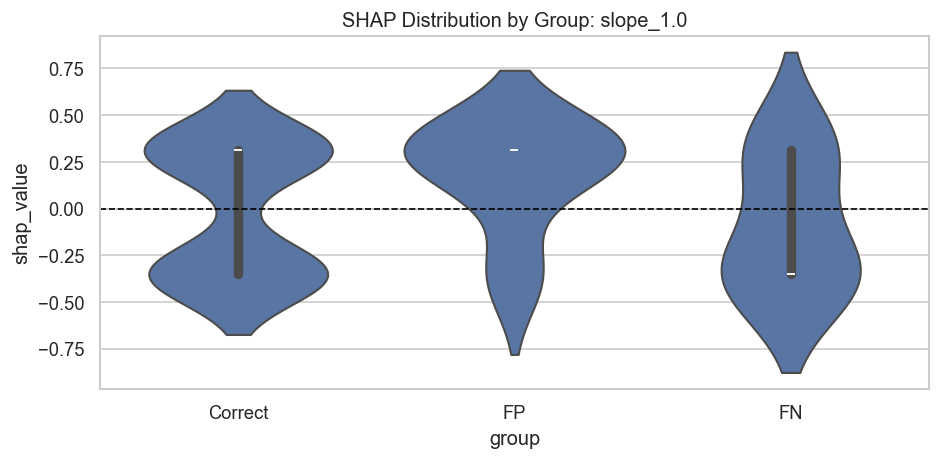

Saved SHAP group comparison CSVs and plots.


In [39]:
# Signed SHAP group comparison for top features.
signed_mean_by_group = (
    shap_df.groupby('group')
    .apply(lambda g: g.mean(), include_groups=False)
    .T
)

signed_mean_by_group.loc[top_features].to_csv(out_dir / 'top12_signed_mean_shap_by_group.csv')

for feat in top_features[:6]:
    plt.figure(figsize=(8, 4))
    sns.violinplot(data=pd.DataFrame({'group': shap_df['group'], 'shap_value': shap_df[feat]}), x='group', y='shap_value', order=['Correct', 'FP', 'FN'])
    plt.axhline(0.0, color='black', linestyle='--', linewidth=1)
    plt.title(f'SHAP Distribution by Group: {feat}')
    plt.tight_layout()
    safe_name = feat.replace('/', '_')
    plt.savefig(out_dir / f'shap_violin_{safe_name}.png', bbox_inches='tight')
    plt.show()

print('Saved SHAP group comparison CSVs and plots.')


Group SHAP plots are the key error-diagnosis plots.
If SHAP values shift a lot between Correct and FP/FN, the model may be over- or under-weighting those features in hard cases.

## Final Summary
- Holdout performance is high, with balanced errors (FP = FN).
- With this sample size, we should trust repeated group patterns more than single outliers.
- SHAP shows a small set of main drivers, we should prioritize ones with consistent signed shifts by group.
- If clinical costs are unequal (misses vs false alarms), we should tune the threshold and re-check FP/FN SHAP differences.